# training.ipynb

Notebook ini adalah **jalur training final yang dapat direproduksi** untuk LPSE-X. Notebook ini menunjukkan bagaimana model akhir dilatih ulang dari artefak split-aware yang sudah dibekukan, lalu dievaluasi kembali dan diekspor ke format yang dipakai pada inference.

Fokus notebook ini adalah memberi pembaca alur yang **jelas, meyakinkan, dan dapat dijalankan ulang** tanpa mengulang seluruh pipeline dari nol. Proses yang lebih besar seperti pembentukan raw split, materialisasi fitur, dan diagnostik tambahan tetap berada di modul `src/` dan utilitas `scripts/`.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import onnxruntime as rt
from IPython.display import display
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from onnxmltools import convert_xgboost
from onnxmltools.convert.common.data_types import FloatTensorType
from src.model import compute_sample_weights

plt.style.use('seaborn-v0_8-whitegrid')

## A. Ringkasan Artefak dan Prasyarat

Sebelum training dijalankan, notebook ini membaca artefak inti berikut:

- `train_data/features.parquet` dan `train_data/labels.parquet`
- `test_data/features.parquet` dan `test_data/labels.parquet`
- `models/best_params.json`
- `models/calibration.json`
- `data/processed/feature_manifest.json`
- `data/processed/split_metadata.json`

Bagian ini penting agar pembaca langsung melihat **skala data, jumlah fitur, batas split temporal, dan konfigurasi training** yang dipakai pada model final.

In [2]:
feature_manifest = json.loads(Path("data/processed/feature_manifest.json").read_text())
split_metadata = json.loads(Path("data/processed/split_metadata.json").read_text())
calibration = json.loads(Path("models/calibration.json").read_text())
best_params = json.loads(Path("models/best_params.json").read_text())

artifact_summary = pd.DataFrame([
    ("train_rows", split_metadata["train_count"]),
    ("test_rows", split_metadata["test_count"]),
    ("split_date", split_metadata["split_date"]),
    ("feature_count", feature_manifest["feature_count"]),
    ("calibration_enabled", calibration["enabled"]),
    ("calibration_samples", calibration["n_calibration_samples"]),
    ("n_rounds", best_params["n_rounds"]),
], columns=["artifact", "value"])

display(artifact_summary)

,artifact,value
0,train_rows,372150
1,test_rows,93034
2,split_date,2023-03-10 07:27:51+00:00
3,feature_count,34
4,calibration_enabled,True
5,calibration_samples,287
6,n_rounds,321


## B. Memuat Data Train/Test yang Sudah Dipisah

Data dibaca langsung dari artefak split yang telah dibekukan. Dengan cara ini, notebook menunjukkan jalur training yang **reproducible** sekaligus tetap menjaga disiplin pemisahan train/test.

In [3]:
train_X = pd.read_parquet("train_data/features.parquet")
train_y = pd.read_parquet("train_data/labels.parquet")["risk_label"]
test_X = pd.read_parquet("test_data/features.parquet")
test_y = pd.read_parquet("test_data/labels.parquet")["risk_label"]

print({
    "train_shape": train_X.shape,
    "test_shape": test_X.shape,
    "train_label_shape": train_y.shape,
    "test_label_shape": test_y.shape,
})

{'train_shape': (372150, 34), 'test_shape': (93034, 34), 'train_label_shape': (372150,), 'test_label_shape': (93034,)}


## C. Distribusi Label dan Skala Benchmark

Distribusi label penting ditampilkan agar pembaca dapat melihat bahwa benchmark ini memiliki kelas risiko yang tidak seimbang, khususnya pada kelompok risiko tertinggi. Ini relevan untuk membaca metrik dan memahami tantangan training.

,train,test
risk_label,,
Low Risk,124351,26358
Medium Risk,223427,58425
High Risk,24372,8251


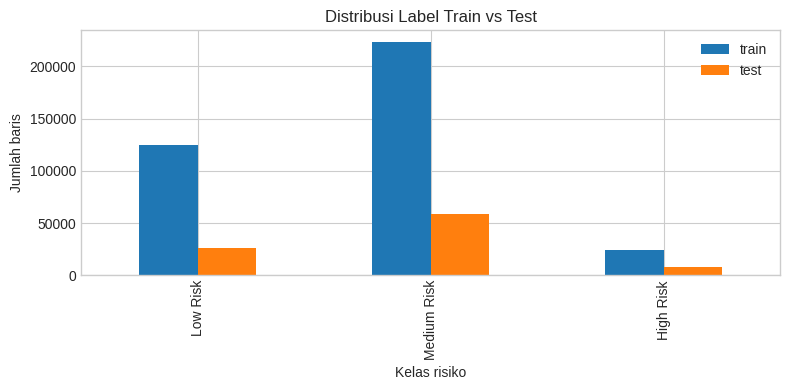

In [4]:
label_map = {0: "Low Risk", 1: "Medium Risk", 2: "High Risk"}
train_dist = train_y.value_counts().sort_index().rename(index=label_map)
test_dist = test_y.value_counts().sort_index().rename(index=label_map)
label_dist = pd.DataFrame({"train": train_dist, "test": test_dist}).fillna(0).astype(int)
display(label_dist)

ax = label_dist.plot(kind="bar", figsize=(8, 4), title="Distribusi Label Train vs Test")
ax.set_ylabel("Jumlah baris")
ax.set_xlabel("Kelas risiko")
plt.tight_layout()
plt.show()

## D. Snapshot Kualitas Fitur

Bagian ini memberikan gambaran cepat tentang kualitas fitur yang masuk ke model akhir: jumlah fitur, sebagian nama fitur, serta tingkat *missing values* terbesar. Ini membantu menjelaskan bahwa notebook tidak hanya melatih model, tetapi juga meninjau kualitas input yang dipakai.

In [5]:
feature_preview = pd.DataFrame({
    "feature_name": train_X.columns,
    "missing_rate_train": train_X.isna().mean().values,
    "missing_rate_test": test_X.isna().mean().values,
}).sort_values("missing_rate_train", ascending=False)

display(feature_preview.head(10))
print("Feature count:", train_X.shape[1])
print("First 10 features:", train_X.columns[:10].tolist())

,feature_name,missing_rate_train,missing_rate_test
17,f_supplier_hist_win_count,0.622733,0.394899
20,f_supplier_hist_max_award,0.622733,0.394899
29,f_supplier_hist_avg_award,0.622733,0.394899
26,f_supplier_capacity_ratio,0.622733,0.394899
21,f_tender_value_zscore_buyer,0.482354,0.322989
25,f_buyer_value_growth_rate,0.480683,0.322979
0,f_tender_value_log,0.477772,0.322882
2,f_price_deviation_ratio,0.477772,0.322882
4,f_award_duration_days,0.477772,0.322882
1,f_award_value_log,0.476888,0.322882


Feature count: 34
First 10 features: ['f_tender_value_log', 'f_award_value_log', 'f_price_deviation_ratio', 'f_main_procurement_category_enc', 'f_award_duration_days', 'f_tender_items_count', 'f_award_items_count', 'f_title_length', 'f_description_length', 'f_tender_value_missing']


## E. Konfigurasi Training Final

Cell ini memuat parameter terbaik yang sudah dikunci pada eksperimen final. Notebook tetap memperlihatkan parameter tersebut secara eksplisit agar pembaca bisa memahami bahwa training akhir dilakukan dengan konfigurasi yang terdokumentasi, bukan parameter tersembunyi.

In [6]:
params = json.loads(Path("models/best_params.json").read_text())
n_rounds = int(params.pop("n_rounds", 449))
weights = compute_sample_weights(train_y)

print("Best params:")
display(pd.DataFrame(sorted(params.items()), columns=["parameter", "value"]))
print({
    "n_rounds": n_rounds,
    "sample_weight_min": float(np.min(weights)),
    "sample_weight_max": float(np.max(weights)),
    "sample_weight_mean": float(np.mean(weights)),
})

Best params:


,parameter,value
0,colsample_bytree,7.993292e-01
1,gamma,7.799726e-01
2,learning_rate,2.536999e-01
3,max_depth,5.000000e+00
4,min_child_weight,2.000000e+00
5,reg_alpha,3.332365e-08
6,reg_lambda,6.245760e-01
7,subsample,8.927976e-01


{'n_rounds': 321, 'sample_weight_min': 0.5552149024066027, 'sample_weight_max': 5.0898572131954705, 'sample_weight_mean': 0.9999999999999997}


## F. Retraining Model Final

Bagian ini melatih ulang model XGBoost final menggunakan artefak fitur yang sudah dibekukan dan parameter terbaik yang telah dipilih sebelumnya. Output utama dari tahap ini adalah `models/xgb_model.ubj`.

In [7]:
model = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    tree_method="hist",
    seed=42,
    n_estimators=n_rounds,
    n_jobs=-1,
    **params,
)
model.fit(
    train_X,
    train_y,
    sample_weight=weights,
    eval_set=[(train_X, train_y)],
    verbose=50,
)
model.save_model("models/xgb_model.ubj")
print({
    "saved_ubj": Path("models/xgb_model.ubj").exists(),
    "trained_feature_count": train_X.shape[1],
})


[0]	validation_0-mlogloss:0.79651


[50]	validation_0-mlogloss:0.00788


[100]	validation_0-mlogloss:0.00281


[150]	validation_0-mlogloss:0.00210


[200]	validation_0-mlogloss:0.00194


[250]	validation_0-mlogloss:0.00189


[300]	validation_0-mlogloss:0.00186


[320]	validation_0-mlogloss:0.00183


{'saved_ubj': True, 'trained_feature_count': 34}


## G. Evaluasi pada Held-Out Test Split

Evaluasi dilakukan langsung terhadap test split yang sudah dipisahkan sebelumnya. Bagian ini menampilkan metrik utama, classification report, dan confusion matrix agar pembaca bisa melihat kualitas model dari beberapa sudut sekaligus.

{'accuracy': 0.9899, 'macro_f1': 0.9831, 'weighted_f1': 0.9899}
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     26358
           1       0.99      0.99      0.99     58425
           2       0.99      0.94      0.96      8251

    accuracy                           0.99     93034
   macro avg       0.99      0.98      0.98     93034
weighted avg       0.99      0.99      0.99     93034



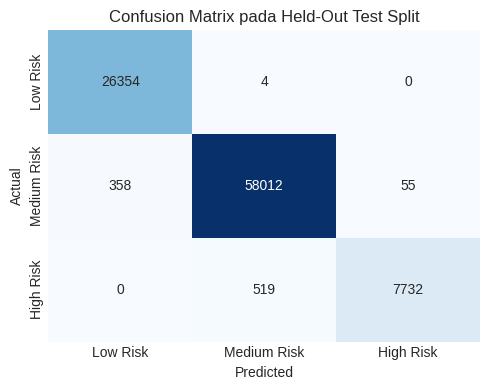

In [8]:
preds = model.predict(test_X)
probs = model.predict_proba(test_X)
metrics_summary = {
    "accuracy": round(float(accuracy_score(test_y, preds)), 4),
    "macro_f1": round(float(f1_score(test_y, preds, average="macro")), 4),
    "weighted_f1": round(float(f1_score(test_y, preds, average="weighted")), 4),
}
print(metrics_summary)
print(classification_report(test_y, preds))

cm = confusion_matrix(test_y, preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=[label_map[i] for i in range(3)],
            yticklabels=[label_map[i] for i in range(3)])
plt.title('Confusion Matrix pada Held-Out Test Split')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## H. Snapshot Skor Prediksi pada Sampel Risiko Tertinggi

Untuk memperlihatkan nilai operasional model, cell berikut menampilkan beberapa baris dengan probabilitas *High Risk* tertinggi. Ini membantu pembaca melihat bagaimana model dapat dipakai sebagai mesin pemeringkatan prioritas review.

In [9]:
risk_table = pd.DataFrame({
    "predicted_class": preds,
    "p_low": probs[:, 0],
    "p_medium": probs[:, 1],
    "p_high": probs[:, 2],
})
display(risk_table.sort_values("p_high", ascending=False).head(10))

,predicted_class,p_low,p_medium,p_high
89424,2,6.247147e-11,4.315370e-11,1.0
55839,2,1.278023e-10,5.205604e-09,1.0
89605,2,1.046019e-09,1.378649e-08,1.0
91782,2,4.400085e-09,1.799349e-08,1.0
23873,2,7.845103e-10,1.316595e-08,1.0
25608,2,3.112021e-09,3.667544e-08,1.0
39221,2,6.874723e-10,1.698758e-08,1.0
88836,2,1.001822e-09,3.064698e-08,1.0
53007,2,1.871776e-09,1.001664e-08,1.0
23249,2,7.502688e-10,7.941974e-09,1.0


## I. Ekspor Model ONNX dan Cek Paritas Dasar

Selain artefak `.ubj`, notebook juga mengekspor model ke format `ONNX` agar jalur inference lokal memiliki opsi deployment yang lebih ringan dan interoperable. Di akhir cell, kami tampilkan satu cek paritas dasar agar pembaca melihat bahwa artefak ONNX benar-benar menghasilkan output yang dapat dibaca.

In [10]:
renamed = train_X.copy()
renamed.columns = [f"f{i}" for i in range(renamed.shape[1])]
onnx_model_src = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    tree_method="hist",
    seed=42,
    n_estimators=n_rounds,
    n_jobs=-1,
    **params,
)
onnx_model_src.fit(renamed, train_y, sample_weight=weights)
initial_type = [("float_input", FloatTensorType([None, renamed.shape[1]]))]
onnx_model = convert_xgboost(onnx_model_src, initial_types=initial_type)
with open("models/xgb_model.onnx", "wb") as f:
    f.write(onnx_model.SerializeToString())

sample = renamed.iloc[[0]].to_numpy(dtype=np.float32)
sess = rt.InferenceSession("models/xgb_model.onnx")
input_name = sess.get_inputs()[0].name
onnx_outputs = sess.run(None, {input_name: sample})
print({
    "saved_onnx": Path("models/xgb_model.onnx").exists(),
    "onnx_output_count": len(onnx_outputs),
    "onnx_output_shapes": [getattr(o, 'shape', None) for o in onnx_outputs],
    "first_output_preview": onnx_outputs[0][0].tolist() if len(onnx_outputs) > 0 else None,
})

{'saved_onnx': True, 'onnx_output_count': 2, 'onnx_output_shapes': [(1,), (1, 3)], 'first_output_preview': 1}
